In [1]:
#Clasificacion
 
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris # datos de iris
from sklearn.tree import DecisionTreeClassifier # árbol de decisión para clasificación
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
iris = load_iris()
irisdf = pd.DataFrame(iris.data, columns=iris.feature_names)
irisdf['specie'] = iris.target
irisdf.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),specie
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X_train,X_test,Y_train, Y_test = train_test_split(irisdf.drop('specie',axis=1),irisdf['specie'],test_size=0.2,random_state=42)

In [4]:
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [5]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [6]:
Y_train

22     0
15     0
65     1
11     0
42     0
      ..
71     1
106    2
14     0
92     1
102    2
Name: specie, Length: 120, dtype: int64

In [7]:
#Crear y entrenar el modelo de clasificacion

treeclass = DecisionTreeClassifier(max_depth=2,random_state=42)
treeclass.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [8]:
#Visualizar el arbol
fn = iris.feature_names
cn = iris.target_names
fig,axes = plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=300)
tree.plot_tree(treeclass,feature_names=fn,class_names=cn,filled=True)

[Text(0.4, 0.8333333333333334, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]\nclass = versicolor'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal length (cm) <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]\nclass = versicolor'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.053\nsamples = 37\nvalue = [0, 36, 1]\nclass = versicolor'),
 Text(0.8, 0.16666666666666666, 'gini = 0.206\nsamples = 43\nvalue = [0, 5, 38]\nclass = virginica')]

In [9]:
#Evaluar el modelo con los datos de entenamiento
print("Accurancy del modelo: {}",format(treeclass.score(X_train,Y_train)))

Accurancy del modelo: {} 0.95


In [10]:
def metrics_score(actual, predicted, labels=None):
    print("\nReporte de clasificación:")
    print(metrics.classification_report(actual, predicted, target_names=labels if labels is not None else None))
 
    cm = metrics.confusion_matrix(actual, predicted)
    print("\nMatriz de confusión:")
    print(cm)
 
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels if labels is not None else sorted(set(actual)),
                yticklabels=labels if labels is not None else sorted(set(actual)),
                cmap="Blues")
    plt.ylabel('Valor Real')
    plt.xlabel('Valor Predicho')
    plt.title('Matriz de Confusión')
    plt.show()


Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


Matriz de confusión:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


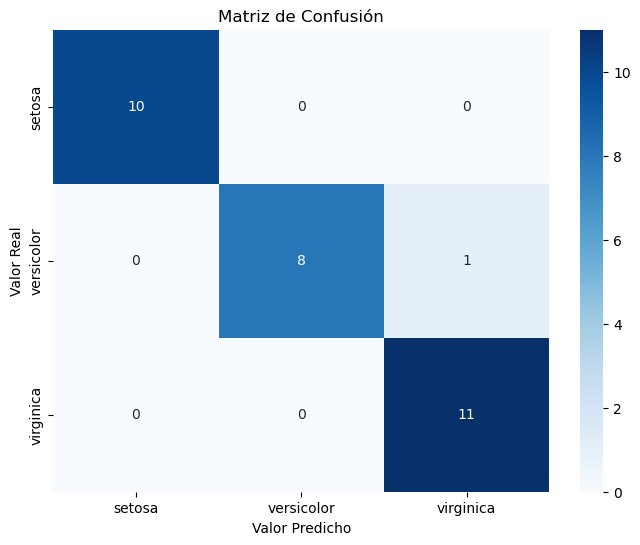

In [27]:
#probar y evaluar el modelo
Y_pred = treeclass.predict(X_test)
metrics_score(Y_test,Y_pred,labels=iris.target_names)

In [12]:
Y_pred

array([1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [14]:
print(Y_test)

73     1
18     0
118    2
78     1
76     1
31     0
64     1
141    2
68     1
82     1
110    2
12     0
36     0
9      0
19     0
56     1
104    2
69     1
55     1
132    2
29     0
127    2
26     0
128    2
131    2
145    2
108    2
143    2
45     0
30     0
Name: specie, dtype: int64


In [22]:
print(f'Accuracy del modelo: {metrics.accuracy_score(Y_test, Y_pred)}')
print(f'Precisión del modelo: {metrics.precision_score(Y_test, Y_pred, average='macro')}')

Accuracy del modelo: 0.9666666666666667
Precisión del modelo: 0.9722222222222222


In [20]:
#Cross-Validation
kfold = KFold(n_splits = 5, shuffle=True, random_state = 42)
scores = cross_val_score(treeclass, irisdf.drop('specie', axis =1),irisdf['specie'], cv=kfold, scoring = 'accuracy')
print(scores)
print(f'Accuracy promedio: {scores.mean()}')

[0.96666667 0.96666667 0.93333333 0.93333333 0.93333333]
Accuracy promedio: 0.9466666666666667


In [21]:
kfold.n_splits

5

Se tiene una muestra más representativa del dataset con la validación cruzada

In [26]:
Y_pred

array([1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [25]:
print(treeclass.predict_proba(X_test))

[[0.         0.97297297 0.02702703]
 [1.         0.         0.        ]
 [0.         0.11627907 0.88372093]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [0.         0.97297297 0.02702703]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [0.         0.97297297 0.02702703]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [0.         0.11627907 0.88372093]
 [0.         0.11627907 0.88372093]
 [0.         0.11627907 0.88372093]
 [0.         0.11627907 0.88372093]
 [0.         0.11627907 0.88

La tabla de probabilidades ayuda a saber la decisión que se va a llevar acabo

In [32]:
irisnl = pd.read_csv('https://raw.githubusercontent.com/omarmendoza564/datos/refs/heads/main/datos/iris_dataset_sintetico.csv')
irisnl.drop('id',axis=1, inplace=True)
irisnl

,sepal_length,sepal_width,petal_length,petal_width
0,6.17,4.03,3.98,1.24
1,5.57,3.15,4.84,0.51
2,6.03,2.15,1.15,2.43
3,7.48,2.83,4.18,0.73
4,6.83,4.39,4.82,0.43
...,...,...,...,...
295,6.11,3.76,6.12,1.34
296,4.46,2.37,4.27,2.50
297,4.93,2.82,6.66,1.55
298,7.69,3.75,6.77,0.11


In [34]:
X = np.array(irisnl)
X

array([[6.17, 4.03, 3.98, 1.24],
       [5.57, 3.15, 4.84, 0.51],
       [6.03, 2.15, 1.15, 2.43],
       ...,
       [4.93, 2.82, 6.66, 1.55],
       [7.69, 3.75, 6.77, 0.11],
       [5.2 , 2.03, 5.89, 1.43]])

In [36]:
print(treeclass.predict_proba(X))

[[0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [0.         0.11627907 0.88372093]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.11627907 0.88372093]
 [0.         0.11627907 0.88372093]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [0.         0.97297297 0.02702703]
 [1.         0.         0.        ]
 [0.         0.97297297 0.02702703]
 [0.         0.11627907 0.88372093]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.97297297 0.02702703]
 [0.         0.97297297 0.02702703]
 [1.         0.         0.        ]
 [0.         0.97297297 0.02702703]
 [0.         0.97297297 0.02702703]
 [1.         0.         0.  

/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [37]:
Y = treeclass.predict(X)
Y

/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1, 2, 0, 1, 2, 2, 1, 2, 0, 0, 2, 2, 2, 0, 2, 0, 1, 0, 1, 2, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 2, 1, 2, 1, 2, 0, 0, 1, 1, 0, 2, 1, 1, 0, 1,
       2, 0, 1, 2, 1, 0, 1, 1, 2, 1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1,
       0, 1, 1, 2, 2, 1, 1, 2, 0, 1, 0, 1, 2, 2, 2, 1, 0, 1, 0, 2, 1, 2,
       0, 2, 2, 0, 1, 2, 1, 0, 0, 2, 0, 2, 1, 2, 0, 0, 1, 2, 1, 1, 2, 1,
       1, 1, 0, 2, 2, 1, 1, 2, 0, 1, 0, 1, 2, 2, 0, 0, 2, 2, 2, 2, 1, 0,
       0, 1, 1, 1, 0, 2, 1, 0, 2, 1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 1, 1, 2,
       0, 2, 2, 0, 2, 1, 0, 0, 2, 2, 0, 1, 1, 0, 2, 0, 2, 1, 1, 2, 1, 0,
       2, 1, 1, 0, 1, 1, 0, 2, 2, 1, 1, 1, 0, 1, 1, 2, 1, 2, 0, 1, 0, 1,
       0, 2, 2, 0, 1, 2, 0, 1, 0, 0, 1, 0, 2, 0, 2, 2, 2, 0, 1, 2, 1, 0,
       0, 2, 0, 2, 2, 0, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 0, 2, 2, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 2, 0, 2, 2, 0, 1, 2, 2, 0, 1, 1, 2, 1, 0, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2])

In [39]:
irisnl['specie'] = Y
irisnl['specie'].replace({0: 'setosa', 1: 'vericolor', 2: 'Iris-Virginica'}, inplace = True)


/tmp/ipykernel_5446/1813740405.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  irisnl['specie'].replace({0: 'setosa', 1: 'vericolor', 2: 'Iris-Virginica'}, inplace = True)


In [40]:
irisnl

,sepal_length,sepal_width,petal_length,petal_width,specie
0,6.17,4.03,3.98,1.24,vericolor
1,5.57,3.15,4.84,0.51,Iris-Virginica
2,6.03,2.15,1.15,2.43,setosa
3,7.48,2.83,4.18,0.73,vericolor
4,6.83,4.39,4.82,0.43,Iris-Virginica
...,...,...,...,...,...
295,6.11,3.76,6.12,1.34,Iris-Virginica
296,4.46,2.37,4.27,2.50,vericolor
297,4.93,2.82,6.66,1.55,Iris-Virginica
298,7.69,3.75,6.77,0.11,Iris-Virginica


In [41]:
print('Distribución de la especie en el dataset sintetico')
irisnl['specie'].value_counts()

Distribución de la especie en el dataset sintetico


specie
vericolor         116
Iris-Virginica    103
setosa             81
Name: count, dtype: int64

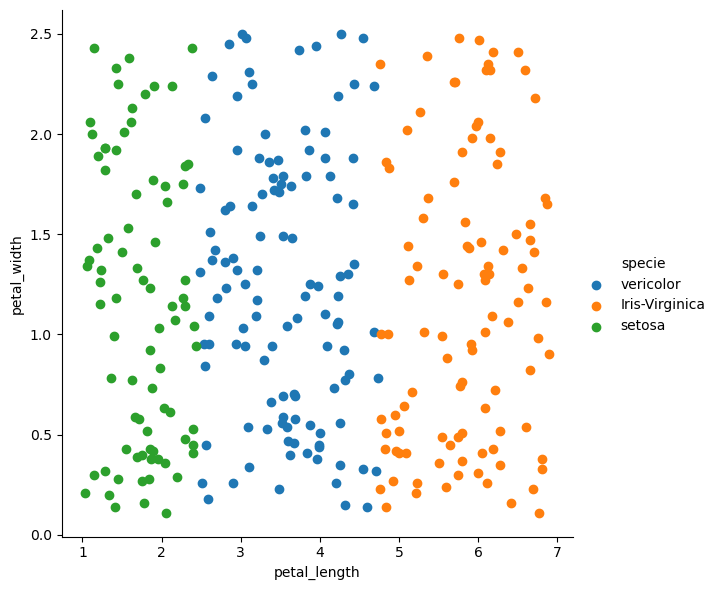

In [47]:
sns.FacetGrid(irisnl, hue='specie', height = 6).map(plt.scatter, 'petal_length', 'petal_width').add_legend()
plt.show()

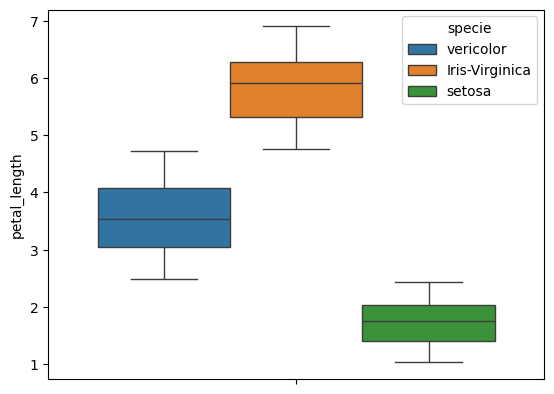

In [49]:
#Boxplot
sns.boxplot(hue='specie', y ='petal_length', data=irisnl)
plt.show()